<a href="https://colab.research.google.com/github/lorenzobalzani/nlp_assigments/blob/master/project/nlp_project_emotion_trigger_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-task neural network for emotion classification and trigger extraction in multi-utterances dialogs
## Project report for the Natural Language Processing course

### Authors: Lorenzo Balzani, Thomas Guizzetti, and Alessia Deana.

# Setup

In [1]:
%%capture
%pip install evaluate transformers[torch] huggingface_hub gdown
!sudo apt-get install git-lfs # for hugging-face hub

import gdown
import json
import pandas as pd
from typing import List, Dict, Tuple
from tqdm import tqdm

from transformers import BertModel, BertTokenizer, AutoModel
from huggingface_hub import PyTorchModelHubMixin
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, AutoTokenizer, EarlyStoppingCallback, pipeline, get_linear_schedule_with_warmup
from datasets import Dataset, DatasetDict, load_dataset
import evaluate
import statistics

from collections import Counter
from itertools import chain

import seaborn as sns
import matplotlib.pyplot as plt

random_state: int = 42

## Hugging-Face (Optional)

In [2]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Token: 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


# Dataset

## Download and Pre-Processing

In [3]:
training_set_filename = f"MELD_train_efr.json"

try:
  print(f"Attempting to download {training_set_filename} from Drive...")
  file_id = "1wVNU2XvvhqjaGXZM-JLJwOt97gt4g9j2"  # Extracted File ID from your provided URL
  url = f"https://drive.google.com/uc?id={file_id}"
  gdown.download(url, training_set_filename, quiet=False)
  with open(training_set_filename, 'r') as file:
        training_set_json = json.load(file)

  print(f"\nSuccessfully downloaded {training_set_filename} from Drive!")
except:
  print(f"Error loading {training_set_filename} set from Drive")

Attempting to download MELD_train_efr.json from Drive...


Downloading...
From: https://drive.google.com/uc?id=1wVNU2XvvhqjaGXZM-JLJwOt97gt4g9j2
To: /content/MELD_train_efr.json
100%|██████████| 5.18M/5.18M [00:00<00:00, 34.5MB/s]



Successfully downloaded MELD_train_efr.json from Drive!


In [4]:
df = pd.DataFrame(training_set_json)

# Check the number of NaN values within the lists in the 'triggers' column
nan_count_before = df["utterances"].apply(lambda x: pd.Series(x).isna().sum()).sum()

# Display the number of NaN values
print(f"Number of NaN values in the 'triggers' column lists: {nan_count_before}")

# Replace NaN values within each list in the 'triggers' column with 0.0
df["triggers"] = df["triggers"].apply(lambda x: [0.0 if pd.isna(val) else val for val in x])

# Check again the number of NaN values within the lists in the 'triggers' column
nan_count_after = df["triggers"].apply(lambda x: pd.Series(x).isna().sum()).sum()

# Display the number of NaN values after replacing with 0s
print(f"Number of NaN values in the 'triggers' column lists after replacing: {nan_count_after}")

Number of NaN values in the 'triggers' column lists: 0
Number of NaN values in the 'triggers' column lists after replacing: 0


In [5]:
train_ratio: float = 0.8
val_ratio: float = 0.1
test_ratio: float = 0.1
columns_to_keep: List[str] = ["utterances", "emotions", "triggers"]

labels_emotions = [label for label in df.explode("emotions")["emotions"].unique()]
id2label_emotions = {idx:label for idx, label in enumerate(labels_emotions)}
label2id_emotions = {label:idx for idx, label in enumerate(labels_emotions)}

df["emotions"] = df["emotions"].apply(lambda emotions: [label2id_emotions[emotion] for emotion in emotions])

train_data, temp_data = train_test_split(df, test_size=(1-train_ratio), random_state=random_state)
eval_data, test_data = train_test_split(temp_data, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=random_state)
train_data = train_data[columns_to_keep].reset_index(drop=True)
eval_data = eval_data[columns_to_keep].reset_index(drop=True)
test_data = test_data[columns_to_keep].reset_index(drop=True)

try:
  dataset_hf = DatasetDict({
      "train":  Dataset.from_pandas(train_data),
      "test": Dataset.from_pandas(test_data),
      "eval": Dataset.from_pandas(eval_data),
  })
  dataset_hf.push_to_hub("balzanilo/dialogs-mtl-dataset", private=False)
except Exception:
  print("Error: you must be logged on the HuggingFace Hub to upload the dataset.")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/638 [00:00<?, ?B/s]

## PyTorch Dataset Adaptation

In [6]:
class EmotionTriggerDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_tokens_per_sentence: int, pad_targets: bool = False):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_tokens_per_sentence = max_tokens_per_sentence
        self.__pad_targets = pad_targets

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        if type(idx) == list:
          idx = idx[0] # ONLY works with batch_size = 1
        tokenized_dialogue = self.tokenizer(self.dataset.iloc[idx]["utterances"], truncation=True, padding="max_length", max_length=self.max_tokens_per_sentence, return_tensors='pt')

        emotions = self.dataset.iloc[idx]["emotions"]
        triggers = self.dataset.iloc[idx]["triggers"]

        if self.__pad_targets:
          emotion_labels = torch.nn.functional.pad(torch.tensor(emotions), (0, self.max_tokens_per_sentence - len(emotions)), value=-1)
          trigger_labels = torch.nn.functional.pad(torch.tensor(triggers), (0, self.max_tokens_per_sentence - len(triggers)), value=-1)
        else:
          emotion_labels = emotions
          trigger_labels = triggers

        return {"input_ids": tokenized_dialogue["input_ids"],
                "attention_mask": tokenized_dialogue["attention_mask"],
                "emotions": torch.LongTensor(emotion_labels),
                "triggers": torch.FloatTensor(trigger_labels)}

In [7]:
encoder_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(encoder_model_name)
max_tokens_per_sentence: int = 25
train_dataset = EmotionTriggerDataset(train_data, roberta_tokenizer, max_tokens_per_sentence=max_tokens_per_sentence)
eval_dataset = EmotionTriggerDataset(eval_data, roberta_tokenizer, max_tokens_per_sentence=max_tokens_per_sentence)
test_dataset = EmotionTriggerDataset(test_data, roberta_tokenizer, max_tokens_per_sentence=max_tokens_per_sentence)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
eval_dataloader = DataLoader(eval_dataset, batch_size=1, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [8]:
for batch_data in train_dataloader:
    # Extract information about the batch
    n_sentences = batch_data["input_ids"].shape[0]
    n_tokens = batch_data["input_ids"].shape[-1]
    n_emotions = batch_data["emotions"].shape[0]
    n_triggers = batch_data["triggers"].shape[0]

    # Display batch information
    print(f"Batch Information - Batch Size: 1, Sentences: {n_sentences}, Tokens per Sentence: {n_tokens}, Emotions: {n_emotions}, Triggers: {n_triggers}")
    break

Batch Information - Batch Size: 1, Sentences: 10, Tokens per Sentence: 25, Emotions: 10, Triggers: 10


# Baselines

## Random Classifier

In [9]:
class RandomClassifier:
    def __init__(self, num_emotions: int, seed: int) -> None:
        self.__num_emotions = num_emotions
        np.random.seed(seed)

    def __call__(self, dialogue: List[str]) -> Tuple[List[int], List[int]]:
        emotions = np.random.rand(len(dialogue), self.__num_emotions)
        emotions = emotions / emotions.sum(axis=1, keepdims=True)
        triggers = np.random.randint(2, size=len(dialogue))
        return np.argmax(emotions, axis=1), triggers

random_classifier = RandomClassifier(num_emotions=7, seed=42)
dialogue = ["I feel happy.", "This is a sad moment Hugo, please.", "I am excited!", "Best, Laura!"]
emotions, trigger_probs = random_classifier(dialogue)
print("Emotions:", emotions)
print("Triggers:", trigger_probs)

Emotions: [1 4 6 4]
Triggers: [1 0 0 0]


## Majority Classifier

In [10]:
class MajorityClassifier:
    def __init__(self, data: pd.DataFrame) -> None:
        self.__majority_emotion = self.__calculate_majority_label(data, key="emotions")
        self.__majority_trigger = self.__calculate_majority_label(data, key="triggers")

    def __calculate_majority_label(self, data: pd.DataFrame, key: str) -> int:
        all_lists = [d[1][key] for d in train_data.iterrows()]
        final_list = list(chain(*all_lists))
        most_frequent_item = Counter(final_list).most_common(1)[0][0]
        return int(most_frequent_item)

    def __call__(self, dialogue: List[str]) -> Tuple[List[int], List[int]]:
        emotions = np.tile(self.__majority_emotion, len(dialogue))
        triggers = np.tile(self.__majority_trigger, len(dialogue))
        return emotions, triggers

majority_classifier = MajorityClassifier(train_data)
dialogue = ["I feel happy.", "This is a sad moment Hugo, please.", "I am excited!", "Best, Laura!"]
emotions, trigger_probs = majority_classifier(dialogue)
print("Emotions:", emotions)
print("Triggers:", trigger_probs)

Emotions: [0 0 0 0]
Triggers: [0 0 0 0]


# Our solution: Model Definition

This PyTorch model is designed for emotion and trigger prediction in text data. Here's a breakdown of its components:

1. **Initialization:**
   - `EmotionTriggerModel` is a class that inherits from `nn.Module`.
   - It takes several parameters during initialization:
      - `model_name`: A string specifying the name of a pre-trained transformer model (assumed to be a RoBERTa-based model).
      - `num_emotions`: An integer indicating the number of emotion classes for prediction.
      - `lstm_hidden_size`: An integer specifying the hidden size of the LSTM layer for trigger prediction.
      - `ffnn_hidden_size`: An integer specifying the hidden size of the feed-forward neural networks.
      - `random_state`: An integer representing the random seed for reproducibility.

2. **RoBERTa Model and Tokenizer:**
   - It uses a RoBERTa-based model for sequence classification (`AutoModelForSequenceClassification`) with a specified number of output labels (`num_emotions`).
   - The RoBERTa model is expected to return hidden states (`output_hidden_states=True`).
   - The RoBERTa tokenizer (`AutoTokenizer`) is initialized from the specified `model_name`.

3. **Emotion Feed-forward Neural Network:**
   - A feed-forward neural network for emotion prediction is defined using `nn.Sequential`.
   - It consists of a linear layer, ReLU activation, another linear layer, and a softmax activation function for multi-class emotion prediction.

4. **LSTM for Trigger Prediction:**
   - An LSTM layer is defined for trigger prediction.
   - The input size to the LSTM includes the RoBERTa hidden size and an additional dimension for the predicted emotion.
   - It is a bidirectional LSTM (`bidirectional=True`).

5. **Feed-forward Neural Network for Trigger Prediction:**
   - Another feed-forward neural network is defined for trigger prediction after the LSTM layer.
   - It consists of a linear layer, ReLU activation, another linear layer, and a sigmoid activation function for binary trigger prediction.

6. **Forward Method:**
   - The `forward` method takes input IDs, attention mask, and token type IDs as input parameters.
   - It passes the input through the RoBERTa model to obtain hidden states.
   - The CLS token is extracted from the last hidden states for emotion prediction.
   - Emotion prediction is performed using the feed-forward neural network.
   - The predicted emotion is concatenated with the CLS token and passed through the LSTM layer for trigger prediction.
   - The final trigger prediction is obtained using the feed-forward neural network for triggers.
   - The method returns tensors representing predicted emotions and trigger probabilities.

In summary, this model is a combination of a RoBERTa-based emotion classifier and an LSTM-based trigger predictor for text data. It is designed to jointly predict emotions and triggers in a given sequence of text.

In [47]:
class EmotionTriggerModel(nn.Module, PyTorchModelHubMixin):
    def __init__(self, encoder_model_name: str, num_emotions: int, lstm_hidden_size: int, ffnn_hidden_size: int, random_state: int = None, freeze_encoder: bool = False) -> None:
        super().__init__()

        if random_state is not None:
          torch.manual_seed(random_state)
          torch.cuda.manual_seed_all(random_state)

        # BERT model for emotion prediction
        self.roberta_model = AutoModelForSequenceClassification.from_pretrained(encoder_model_name, num_labels=num_emotions, output_hidden_states=True)
        if freeze_encoder:
            for param in self.roberta_model.parameters():
                param.requires_grad = False

        # Feed-forward neural network for emotion prediction
        self.emotion_ffnn = nn.Sequential(
            nn.Linear(self.roberta_model.config.hidden_size, ffnn_hidden_size),
            nn.ReLU(),
            nn.Linear(ffnn_hidden_size, num_emotions),
        )

        # LSTM for trigger prediction
        self.lstm = nn.LSTM(input_size=self.roberta_model.config.hidden_size + 1, # add the predicted emotion
                            hidden_size=lstm_hidden_size,
                            batch_first=True,
                            bidirectional=True)

        # Feed-forward neural network for trigger prediction
        self.trigger_ffnn = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, ffnn_hidden_size),
            nn.ReLU(),
            nn.Linear(ffnn_hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
      # Get BERT embeddings for each sentence
      roberta_outputs = self.roberta_model(**{"input_ids": input_ids, "attention_mask": attention_mask}).hidden_states[-1]

      # Extract CLS token for emotion prediction
      cls_tokens = roberta_outputs[:, 0, :]

      # Emotion prediction
      emotions_logits = self.emotion_ffnn(cls_tokens)

      # Concatenate predicted emotions (softmax + argmax) with CLS tokens
      emotions = torch.argmax(nn.functional.softmax(emotions_logits, dim=1), dim=1)
      concat_inputs = torch.cat((cls_tokens, emotions.unsqueeze(1)), dim=1)

      # LSTM for trigger prediction
      lstm_outputs, _ = self.lstm(concat_inputs)

      # Feed-forward neural network for trigger prediction
      trigger_probs = self.trigger_ffnn(lstm_outputs)

      return emotions_logits, trigger_probs.squeeze()

## Example usage

In [12]:
encoder_model_name = "roberta-base"
model = EmotionTriggerModel(encoder_model_name, num_emotions=7, lstm_hidden_size=64, ffnn_hidden_size=32, random_state=random_state)
roberta_tokenizer = AutoTokenizer.from_pretrained(encoder_model_name)
dialogue = ["I feel happy.", "This is a sad moment Hugo, please.", "I am excited!", "Best, Laura!"]
emotions, trigger_probs = model(**roberta_tokenizer(dialogue, return_tensors='pt', padding=True, truncation=True))
print("Emotion logits:", emotions)
print("Trigger Probabilities:", trigger_probs)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Emotion logits: tensor([[-0.1195, -0.0462, -0.2287,  0.0244, -0.0431,  0.0193, -0.1269],
        [-0.1280, -0.0452, -0.2351,  0.0316, -0.0525,  0.0148, -0.1244],
        [-0.1435, -0.0536, -0.2251,  0.0174, -0.0490,  0.0047, -0.1292],
        [-0.1452, -0.0496, -0.2304,  0.0162, -0.0595,  0.0139, -0.1264]],
       grad_fn=<AddmmBackward0>)
Trigger Probabilities: tensor([0.4951, 0.4993, 0.5041, 0.5078], grad_fn=<SqueezeBackward0>)


# Our solution: Training

Execute training with a batch size of 1, meaning one dialogue is processed at a time. The model will be fed tokenized dialogues along with their attention masks, resulting in a PyTorch tensor with a shape of `[batch_size, n_sentences, n_tokens_per_sentence]`. This tensor is then passed through the model (after unsqueezing it to remove the first dimension). The model returns two results: emotions and triggers. Two loss functions are computed and combined weighting the values, and the parameters are updated through backward propagation.

## Training: PyTorch Loop(s)

In [13]:
@torch.inference_mode()
def evaluate_model(model, eval_dataloader, epoch_number, criterion_emotion, criterion_trigger, device) -> float:
    model.eval()
    total_loss: float = 0.0
    with torch.no_grad():
        for idx, batch in enumerate(tqdm(eval_dataloader, desc=f"Evaluating after epoch {epoch_number}")):
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)
          emotion_labels = batch["emotions"].to(device)
          trigger_labels = batch["triggers"].to(device)

          emotion_logits, trigger_probs = model(input_ids=input_ids, attention_mask=attention_mask)

          emotion_loss = criterion_emotion(emotion_logits, emotion_labels)
          trigger_loss = criterion_trigger(trigger_probs, trigger_labels)

          loss = 1 * emotion_loss + .1 * trigger_loss # penalize more the emotion, since it holds higher loss values
          total_loss += loss.item()

    return total_loss / len(eval_dataloader)

def train_model(model, num_epochs, train_dataloader, eval_dataloader, optimizer, scheduler, criterion_emotion, criterion_trigger, device, model_url: str) -> Dict[str, List[float]]:
    model.to(device)
    train_losses: List[float] = list()
    eval_losses: List[float] = list()
    best_eval_loss = float("inf")

    for epoch in range(1, num_epochs+1):
      model.train()
      total_loss: float = 0.0
      for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)
          emotion_labels = batch["emotions"].to(device)
          trigger_labels = batch["triggers"].to(device)

          optimizer.zero_grad()

          emotion_logits, trigger_probs = model(input_ids=input_ids, attention_mask=attention_mask)

          emotion_loss = criterion_emotion(emotion_logits, emotion_labels)
          trigger_loss = criterion_trigger(trigger_probs, trigger_labels)

          loss = 1 * emotion_loss + .1 * trigger_loss # penalize more the emotion, since it holds higher loss values
          total_loss += loss.item()

          loss.backward()
          optimizer.step()
          scheduler.step()

      # Avg losses
      avg_train_loss: float = total_loss / len(train_dataloader)
      train_losses.append(avg_train_loss)

      avg_eval_loss: float = evaluate_model(model, eval_dataloader, epoch, criterion_emotion, criterion_trigger, device)
      eval_losses.append(avg_eval_loss)
      print(f"Epoch {epoch}/{num_epochs}, Avg Train Loss: {avg_train_loss:.4f}, Avg Validation Loss: {avg_eval_loss:.4f}")

      # Save the best model
      if avg_eval_loss < best_eval_loss:
        best_eval_loss = avg_eval_loss
        print(f"Saving model to: {model_url}")
        model.save_pretrained(model_url)
        model.push_to_hub(model_url)

    return {"train_loss_history": train_losses, "eval_loss_history": eval_losses}

## Training: Run It!

In [ ]:
seeds: List[int] = [42, 64, 512, 1024, 4096]
n_epochs: int = 8
learning_rate: float = 2e-5
criterion_emotion = nn.CrossEntropyLoss()
criterion_trigger = nn.BCELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_model_name = "roberta-base"
roberta_model_hub_path: str = f"balzanilo/dialogs_{encoder_model_name}"
history_list: List = list()

for seed in seeds:
  model = EmotionTriggerModel(encoder_model_name, num_emotions=7, lstm_hidden_size=64, ffnn_hidden_size=32, random_state=seed)
  optimizer = AdamW(model.parameters(), lr=learning_rate)
  scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(train_data)*n_epochs)
  history = train_model(model, n_epochs, train_dataloader, eval_dataloader, optimizer, scheduler, criterion_emotion, criterion_trigger, device, model_url = roberta_model_hub_path + f"_seed-{seed}")
  history_list.append(history)

## Training: Eval Loss Visualizations

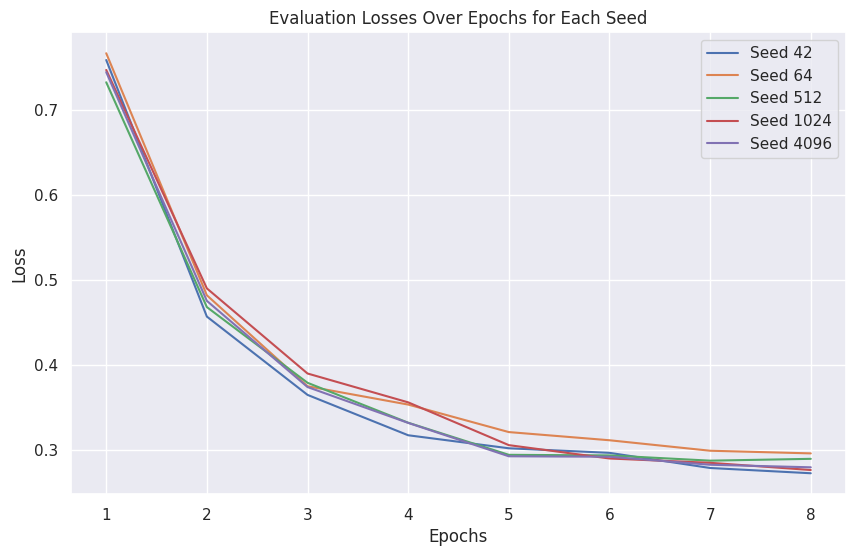

In [28]:
sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))

for seed_idx, model_losses in enumerate([history["eval_loss_history"] for history in history_list]):
    sns.lineplot(x=range(1, len(model_losses) + 1), y=model_losses, label=f'Seed {seeds[seed_idx]}')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evaluation Losses Over Epochs for Each Seed')
plt.legend()
plt.show()

# Our solution: Evaluation

In [61]:
@torch.inference_mode()
def inference(model, input, device: str, print_output: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
  model.eval()
  model.to(device)
  with torch.no_grad():
    emotions, trigger_probs = model(input_ids=input["input_ids"].to(device), attention_mask=input["attention_mask"].to(device))
  if print_output:
    print("Emotions:", emotions)
    print("Ground truth emotions:", input["emotions"])
    print("Trigger Probabilities:", trigger_probs)
    print("Ground truth trigger:", input["triggers"])

  return emotions, trigger_probs

In [51]:
def compute_f1_scores(y_pred: List, y_test: List) -> Tuple[float, float]:
    if len(y_pred) != len(y_test):
        raise ValueError("Predictions and labels must be of the same length")

    # Sequence F1
    sequence_f1_scores = []
    for pred, true in zip(y_pred, y_test):
        if len(pred) != len(true):
            raise ValueError("Prediction and label dialogue lengths must match")
        sequence_f1_scores.append(f1_score(true, pred, average='macro'))

    avg_sequence_f1 = np.mean(sequence_f1_scores)

    # Unrolled Sequence F1
    all_pred = [item for sublist in y_pred for item in sublist]
    all_test = [item for sublist in y_test for item in sublist]
    unrolled_sequence_f1 = f1_score(all_test, all_pred, average='macro')

    return avg_sequence_f1, unrolled_sequence_f1

In [77]:
seeds: List[int] = [42, 64, 512, 1024, 4096]
all_emotions_sequence_f1 = list()
all_emotions_unrolled_f1 = list()
all_triggers_sequence_f1 = list()
all_triggers_unrolled_f1 = list()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder_model_name = "roberta-base"
roberta_model_hub_path: str = f"balzanilo/dialogs_{encoder_model_name}"

with tqdm(total=len(seeds) * len(test_dataloader), position=0, leave=True) as pbar:
  for seed in seeds:
    emotions_predictions = list()
    emotions_labels = list()
    triggers_predictions = list()
    triggers_labels = list()
    model = EmotionTriggerModel.from_pretrained(f"{roberta_model_hub_path}_seed-{seed}",
                                              encoder_model_name=encoder_model_name,
                                              num_emotions=7,
                                              lstm_hidden_size=64,
                                              ffnn_hidden_size=32)
    for idx, batch in enumerate(test_dataloader):
      emotions_labels.append(batch["emotions"])
      triggers_labels.append(batch["triggers"])
      emotions, trigger_probs = inference(model, batch, device)
      emotions_probabilities = torch.softmax(emotions, dim=1)
      emotion_predictions = torch.argmax(emotions_probabilities, dim=1)
      emotions_predictions.append(emotion_predictions.cpu().numpy())
      triggers_prediction = (trigger_probs > .5).int()
      triggers_predictions.append(triggers_prediction.cpu().numpy())
      pbar.update()

    emotions_sequence_f1, emotions_unrolled_sequence_f1 = compute_f1_scores(emotions_predictions, emotions_labels)
    triggers_sequence_f1, triggers_unrolled_sequence_f1 = compute_f1_scores(triggers_predictions, triggers_labels)
    all_emotions_sequence_f1.append(emotions_sequence_f1)
    all_emotions_unrolled_f1.append(emotions_unrolled_sequence_f1)
    all_triggers_sequence_f1.append(triggers_sequence_f1)
    all_triggers_unrolled_f1.append(triggers_unrolled_sequence_f1)

tqdm._instances.clear()

for idx, seed in enumerate(seeds):
  print(f"\n\nSeed {seed}")
  print(f"Emotions -> Sequence F1: {all_emotions_sequence_f1[idx]:.2%}, Unrolled Sequence F1: {all_emotions_unrolled_f1[idx]:.2%}")
  print(f"Triggers -> Sequence F1: {all_triggers_sequence_f1[idx]:.2%}, Unrolled Sequence F1: {all_triggers_unrolled_f1[idx]:.2%}\n")

100%|██████████| 2000/2000 [01:34<00:00, 21.20it/s]



Seed 42
Emotions -> Sequence F1: 90.68%, Unrolled Sequence F1: 93.03%
Triggers -> Sequence F1: 55.97%, Unrolled Sequence F1: 59.90%



Seed 64
Emotions -> Sequence F1: 90.11%, Unrolled Sequence F1: 92.40%
Triggers -> Sequence F1: 57.16%, Unrolled Sequence F1: 60.72%



Seed 512
Emotions -> Sequence F1: 89.66%, Unrolled Sequence F1: 92.15%
Triggers -> Sequence F1: 55.71%, Unrolled Sequence F1: 58.27%



Seed 1024
Emotions -> Sequence F1: 91.06%, Unrolled Sequence F1: 93.42%
Triggers -> Sequence F1: 58.14%, Unrolled Sequence F1: 62.12%



Seed 4096
Emotions -> Sequence F1: 91.31%, Unrolled Sequence F1: 93.16%
Triggers -> Sequence F1: 59.32%, Unrolled Sequence F1: 63.32%



In [80]:
def calculate_avg_and_std_dev(metric_values: List[float]) -> Tuple[float, float]:
    average = statistics.mean(metric_values)
    std_deviation = statistics.stdev(metric_values)
    return average, std_deviation

avg, std_dev = calculate_avg_and_std_dev(all_emotions_sequence_f1)
print(f"Emotions -> Sequence F1 avg: {avg:.2%}, Unrolled Sequence F1 std dev: {std_dev:.2%}")

avg, std_dev = calculate_avg_and_std_dev(all_emotions_unrolled_f1)
print(f"Emotions -> Sequence F1 avg: {avg:.2%}, Unrolled Sequence F1 std dev: {std_dev:.2%}")

avg, std_dev = calculate_avg_and_std_dev(all_triggers_sequence_f1)
print(f"Triggers -> Sequence F1 avg: {avg:.2%}, Unrolled Sequence F1 std dev: {std_dev:.2%}")

avg, std_dev = calculate_avg_and_std_dev(all_triggers_unrolled_f1)
print(f"Triggers -> Sequence F1 avg: {avg:.2%}, Unrolled Sequence F1 std dev: {std_dev:.2%}")

Emotions -> Sequence F1 avg: 90.56%, Unrolled Sequence F1 std dev: 0.68%
Emotions -> Sequence F1 avg: 92.83%, Unrolled Sequence F1 std dev: 0.53%
Triggers -> Sequence F1 avg: 57.26%, Unrolled Sequence F1 std dev: 1.51%
Triggers -> Sequence F1 avg: 60.87%, Unrolled Sequence F1 std dev: 1.95%


# Conclusions: Our solution vs Baselines